# Notebook 01: Churn EDA and Baseline Modeling

## English
This notebook explores telecom churn data, engineers features, and trains a baseline XGBoost model.

**Goals:**
- Profile churn distribution and key customer segments.
- Build a baseline model with clear evaluation metrics.
- Quantify potential business impact from churn reduction.

## Espanol
Este notebook explora datos de churn, genera features y entrena un baseline con XGBoost.

**Objetivos:**
- Perfilar distribucion de churn y segmentos clave.
- Construir un baseline con metricas claras.
- Cuantificar impacto de negocio por reduccion de churn.

In [7]:
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Detectar la raíz del proyecto de forma relativa al notebook
# (Subimos un nivel desde 'notebooks/' a la raíz)
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Ahora las importaciones serán limpias y portátiles
from src.data_loader import load_raw_data, get_data_summary
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración para visualización profesional
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from src.data_loader import load_raw_data, get_data_summary
import sys
from pathlib import Path

# Aseguramos que el notebook encuentre la carpeta 'src' de forma relativa
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Importamos nuestras funciones robustas

# Cargamos los datos
df = load_raw_data()

# Mostramos el resumen ejecutivo
get_data_summary(df)

# Visualizamos las primeras filas para inspección visual
df.head()

✅ Data loaded successfully.
📊 Total records: 7043
🧬 Total variables: 33
🎯 Current churn rate: 26.54%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


/tmp/ipykernel_22344/348598625.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn Label", data=df, palette=colors, ax=ax[0], width=0.5)
/tmp/ipykernel_22344/348598625.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


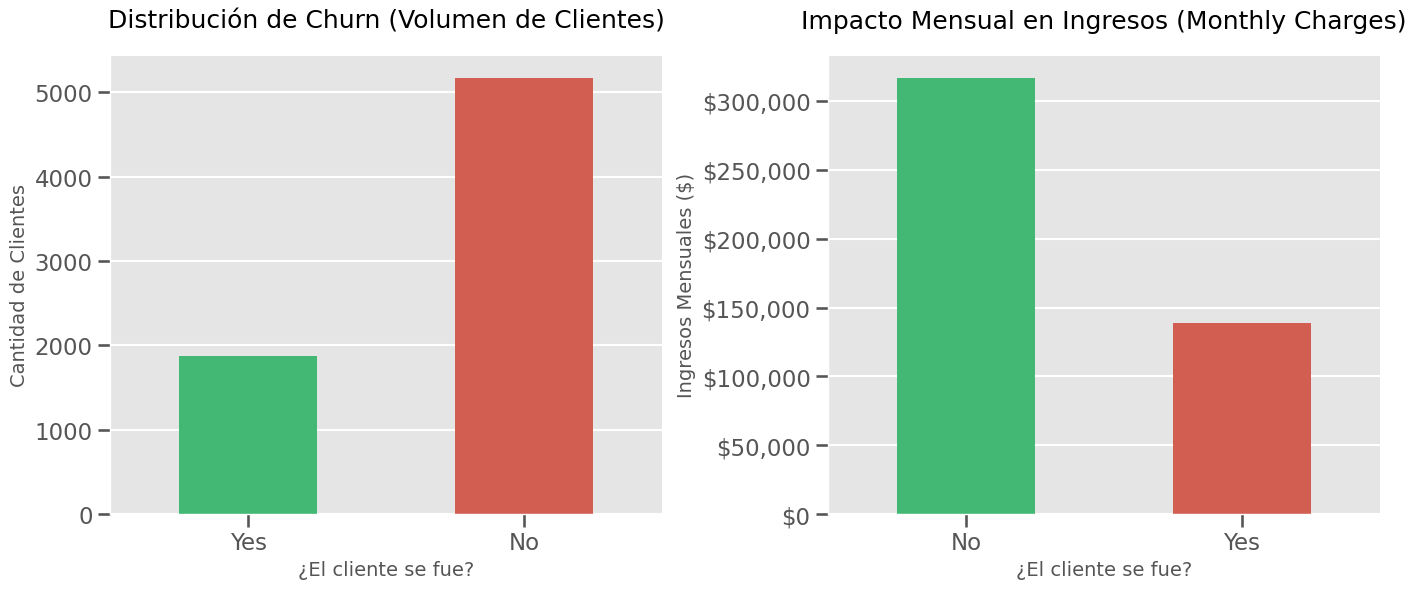

💸 PÉRDIDA MENSUAL ESTIMADA: $139,130.85


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo para el portafolio
sns.set_context("talk")
plt.style.use("ggplot")
colors = ["#2ecc71", "#e74c3c"]  # Verde para leales, Rojo para Churn

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribución de Churn (El Problema)
sns.countplot(x="Churn Label", data=df, palette=colors, ax=ax[0], width=0.5)
ax[0].set_title("Distribución de Churn (Volumen de Clientes)",
                fontsize=18, pad=20)
ax[0].set_xlabel("¿El cliente se fue?", fontsize=14)
ax[0].set_ylabel("Cantidad de Clientes", fontsize=14)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

# 2. Impacto Financiero (El Dinero)
# Calculamos cuánto dinero representan los que se van vs los que se quedan
churn_revenue = df.groupby("Churn Label")[
    "Monthly Charges"].sum().reset_index()
sns.barplot(
    x="Churn Label",
    y="Monthly Charges",
    data=churn_revenue,
    palette=colors,
    ax=ax[1],
    width=0.5,
)
ax[1].set_title("Impacto Mensual en Ingresos (Monthly Charges)",
                fontsize=18, pad=20)
ax[1].set_xlabel("¿El cliente se fue?", fontsize=14)
ax[1].set_ylabel("Ingresos Mensuales ($)", fontsize=14)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

# Formato de números en el eje Y con separadores de miles
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

# Cálculo de pérdida mensual para el reporte
total_loss = df[df["Churn Label"] == "Yes"]["Monthly Charges"].sum()
print(f"💸 PÉRDIDA MENSUAL ESTIMADA: ${total_loss:,.2f}")

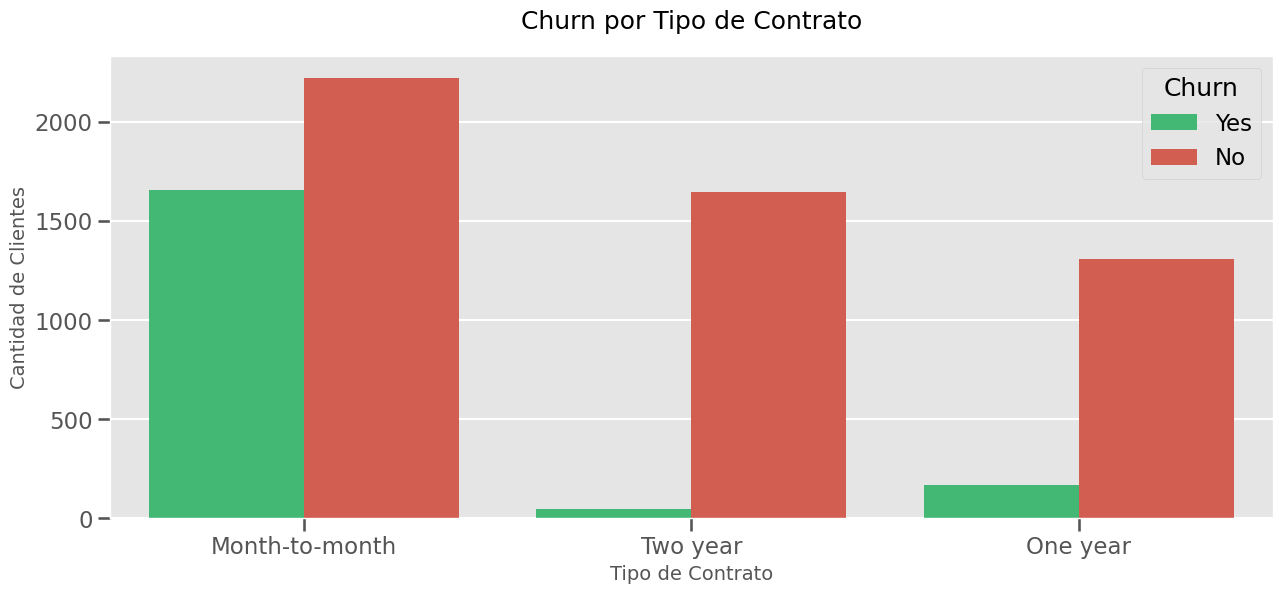

In [10]:
plt.figure(figsize=(15, 6))

# Relación entre Contrato y Churn
sns.countplot(x="Contract", hue="Churn Label", data=df, palette=colors)
plt.title("Churn por Tipo de Contrato", fontsize=18, pad=20)
plt.xlabel("Tipo de Contrato", fontsize=14)
plt.ylabel("Cantidad de Clientes", fontsize=14)
plt.legend(title="Churn", loc="upper right")
plt.show()

/tmp/ipykernel_22344/864972205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=churn_reasons.index, x=churn_reasons.values, palette="magma")


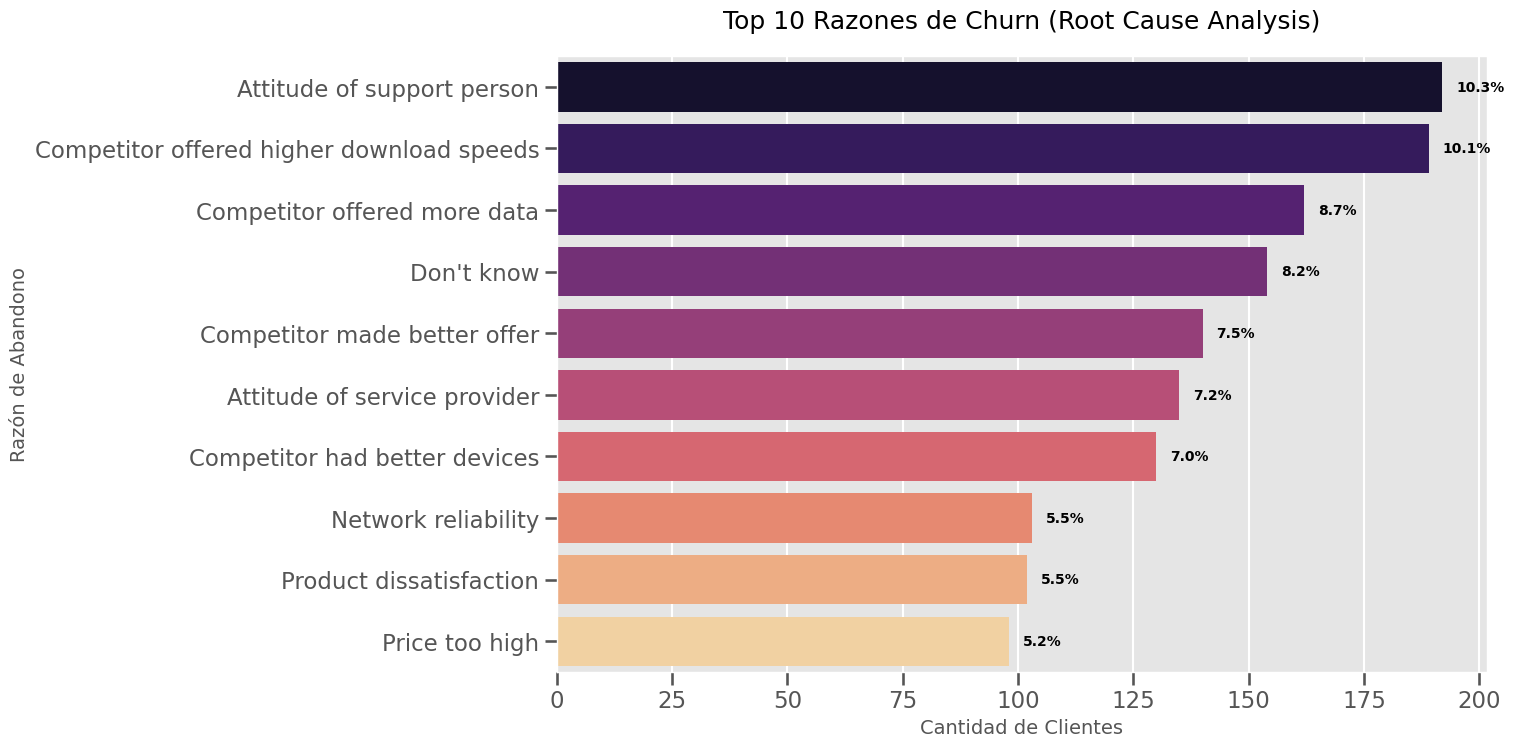

In [11]:
# Filtramos solo a los clientes que se fueron y tienen una razón registrada
churn_reasons = df[df["Churn Label"] ==
                   "Yes"]["Churn Reason"].value_counts().head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y=churn_reasons.index, x=churn_reasons.values, palette="magma")
plt.title("Top 10 Razones de Churn (Root Cause Analysis)", fontsize=18, pad=20)
plt.xlabel("Cantidad de Clientes", fontsize=14)
plt.ylabel("Razón de Abandono", fontsize=14)

# Añadimos etiquetas de porcentaje para impacto visual
total_churn = churn_reasons.sum()
for i, v in enumerate(churn_reasons.values):
    plt.text(
        v + 3,
        i,
        f'{(v/len(df[df["Churn Label"]=="Yes"])*100):.1f}%',
        color="black",
        va="center",
        fontweight="bold",
    )

plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


def preprocess_data(df):
    """
    Limpia y transforma el dataframe para el entrenamiento.
    Optimizado para modelos de ensamble (XGBoost/LightGBM).
    """
    # 1. Eliminar columnas irrelevantes para la predicción (IDs, Ubicaciones exactas, Razones post-mortem)
    cols_to_drop = [
        "CustomerID",
        "Count",
        "Country",
        "State",
        "City",
        "Zip Code",
        "Lat Long",
        "Latitude",
        "Longitude",
        "Churn Label",
        "Churn Reason",
    ]
    df_ml = df.drop(columns=cols_to_drop)

    # 2. Encoding de variables categóricas
    # Usaremos LabelEncoding para variables binarias y One-Hot para el resto
    le = LabelEncoder()

    # Identificar columnas categóricas
    cat_cols = df_ml.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

    return df_ml


def get_train_test_splits(df_ml, target="Churn Value", test_size=0.2):
    """
    Divide los datos y asegura que estén listos para la GPU.
    """
    X = df_ml.drop(columns=[target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    return X_train, X_test, y_train, y_test

In [13]:
from src.preprocessing import preprocess_data, get_train_test_splits

# Transformar el dataset crudo en uno numérico para ML
df_ml = preprocess_data(df)

print("Shape después de preprocessing:", df_ml.shape)
df_ml.head()

Shape después de preprocessing: (7043, 22)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,86,3239
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,67,2701
2,0,0,0,1,8,1,2,1,0,0,...,2,2,0,1,2,99.65,820.50,1,86,5372
3,0,0,1,1,28,1,2,1,0,0,...,2,2,0,1,2,104.80,3046.05,1,84,5003
4,1,0,0,1,49,1,2,1,0,2,...,2,2,0,1,0,103.70,5036.30,1,89,5340


In [14]:
X_train, X_test, y_train, y_test = get_train_test_splits(df_ml)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribución:\n", y_train.value_counts(normalize=True))
print("y_test distribución:\n", y_test.value_counts(normalize=True))

X_train: (5634, 21)
X_test: (1409, 21)
y_train distribución:
 Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test distribución:
 Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [15]:
from src.modeling import train_xgboost, evaluate_model, save_model

# 1. Entrenar en CPU (rápido igual para 7k filas)
model_xgb = train_xgboost(X_train, y_train, X_test, y_test)

# 2. Evaluar
preds, probs = evaluate_model(model_xgb, X_test, y_test)

# 3. Guardar
save_model(model_xgb)

🚀 Starting XGBoost training (CPU)...
[0]	validation_0-logloss:0.56511
[50]	validation_0-logloss:0.17692
[100]	validation_0-logloss:0.14615
[150]	validation_0-logloss:0.14381
[200]	validation_0-logloss:0.14450
[250]	validation_0-logloss:0.14723
[300]	validation_0-logloss:0.14936
[350]	validation_0-logloss:0.15122
[399]	validation_0-logloss:0.15396

📊 MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

    No Churn       0.95      0.95      0.95      1035
       Churn       0.86      0.86      0.86       374

    accuracy                           0.93      1409
   macro avg       0.90      0.91      0.91      1409
weighted avg       0.93      0.93      0.93      1409


🎯 ROC-AUC Score: 0.9819
✅ Model saved to: /workspaces/Proyectos-portafolio/Proyecto 4/models/xgboost_churn_v1.json


/workspaces/Proyectos-portafolio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


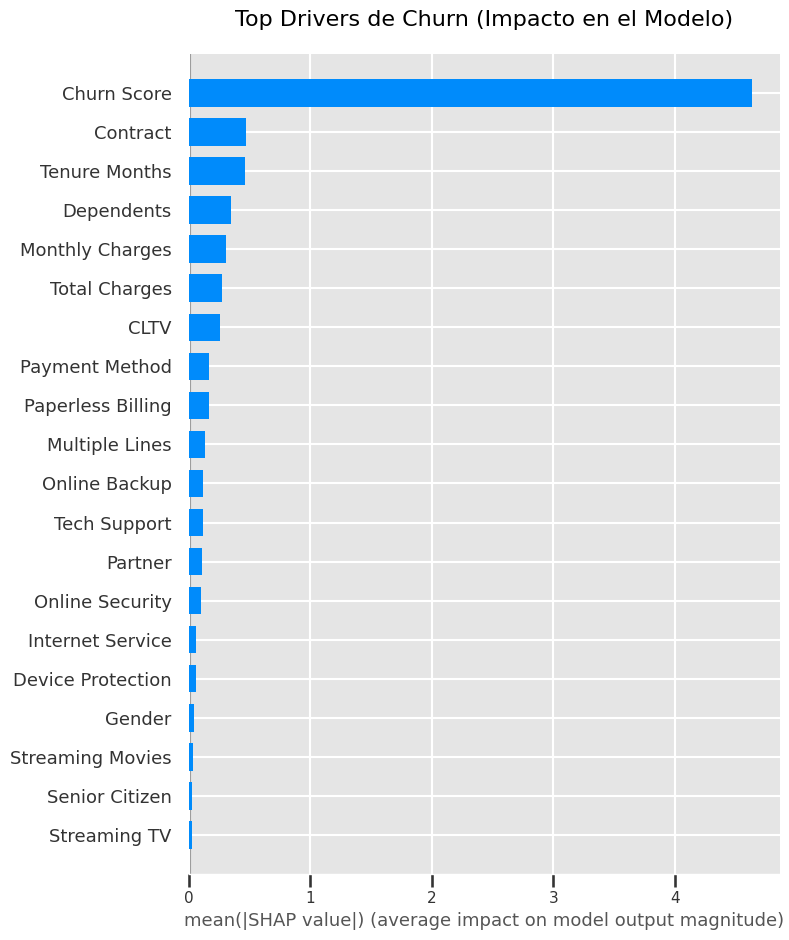

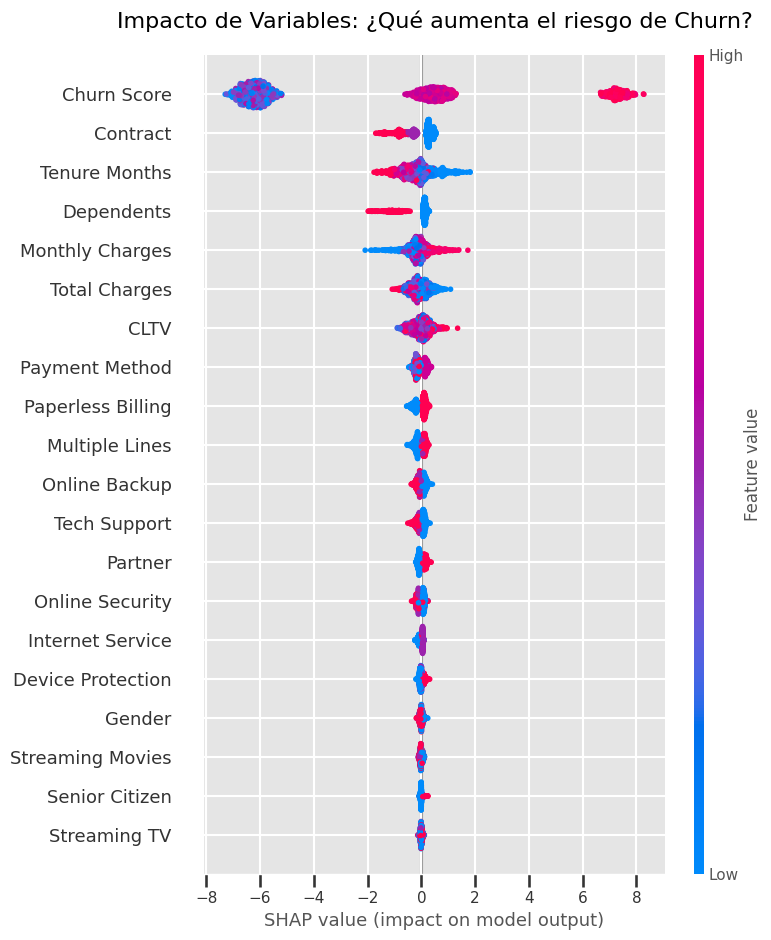

In [ ]:
import shap
import numpy as np

# 1. Convertir a NumPy para evitar el bug
X_test_array = X_test.values

# 2. Inicializar el explicador
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_array)

# 3. Gráfica de Resumen (Bar Plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Drivers de Churn (Impacto en el Modelo)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 4. Gráfica de Densidad (Beeswarm Plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Impacto de Variables: ¿Qué aumenta el riesgo de Churn?",
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Results Snapshot

## English
- Estimated churn loss: $139,130.85 based on historical revenue impact.
- Processed dataset shape: 7,043 rows and 22 features.
- Baseline XGBoost metrics: Accuracy ~0.93, Churn Recall ~0.86, ROC-AUC ~0.9819.
- Model artifact saved for downstream pipeline usage.

## Espanol
- Perdida estimada por churn: $139,130.85 segun impacto historico.
- Dataset procesado: 7,043 filas y 22 features.
- Metricas XGBoost: Accuracy ~0.93, Recall churn ~0.86, ROC-AUC ~0.9819.
- El modelo se guarda para uso en el pipeline.

# Conclusions

## English
- The baseline already performs strongly, especially on churn recall.
- Business impact is material, supporting investment in retention actions.
- Next steps include calibration and threshold optimization for ROI.

## Espanol
- El baseline rinde muy bien, especialmente en recall de churn.
- El impacto de negocio es relevante, justificando acciones de retencion.
- Siguientes pasos: calibracion y optimizacion de umbral para ROI.